## Домашняя работа 3
### Пункт 1
> (1 балл) Выбрать и загрузить датасет с помощью библиотеки Pandas. Датасет должен относиться к задаче регрессии, содержать непрерывные данные.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples

# Настройка графиков
plt.rcParams['figure.figsize'] = (12, 5)

# Загрузка датасета
housing = fetch_california_housing()  # возьмем готовый датасет из sklearn
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nОписательная статистика:")
print(df.describe())
print("\nИнформация о пропусках:")
print(df.isnull().sum())

# проверим на искажения (выбросы через IQR)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print("\nКоличество выбросов по каждому признаку:")
print(outliers)

# Стандартизация (отделим целевую переменную)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nПосле стандартизации:")
print(X_scaled.describe().round(2))

Размер данных: (20640, 9)

Первые 5 строк:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Описательная статистика:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.

### Пункт 2
> (4 балла) Разделить данные на обучающий и проверочный наборы. Решить задачу регрессии, используя библиотеку sklearn несколькими методами (линейная LinearRegression, добавление квадратичных и кубических компонентов с помощью PolynomialFeatures, Lasso, Ridge Regression).

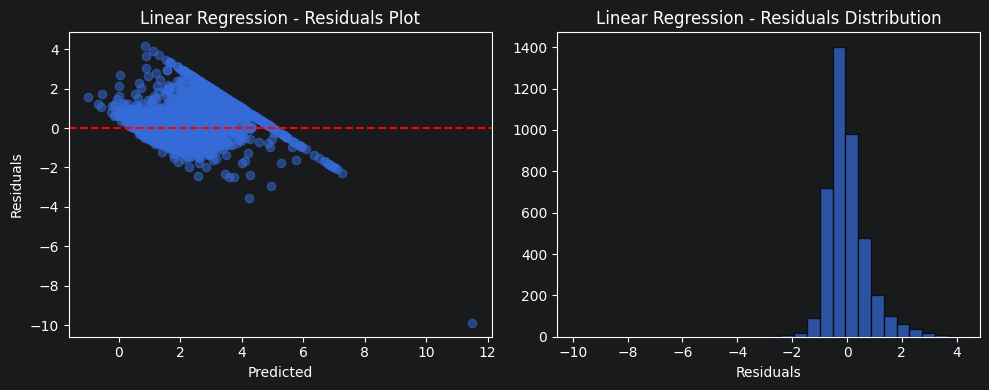

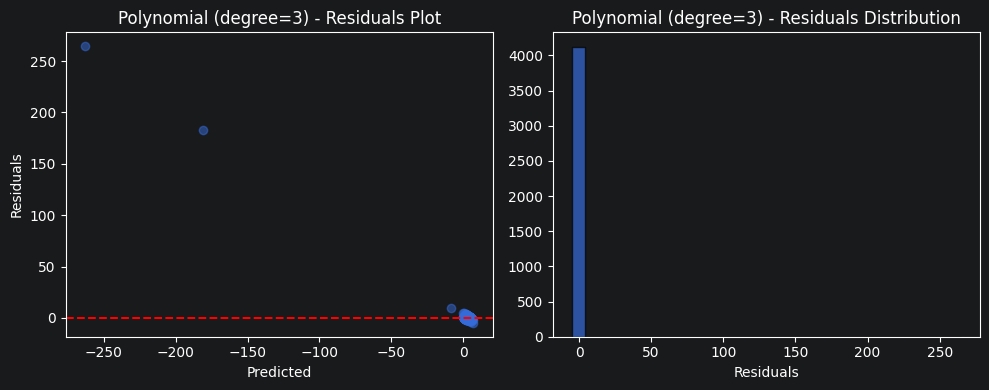

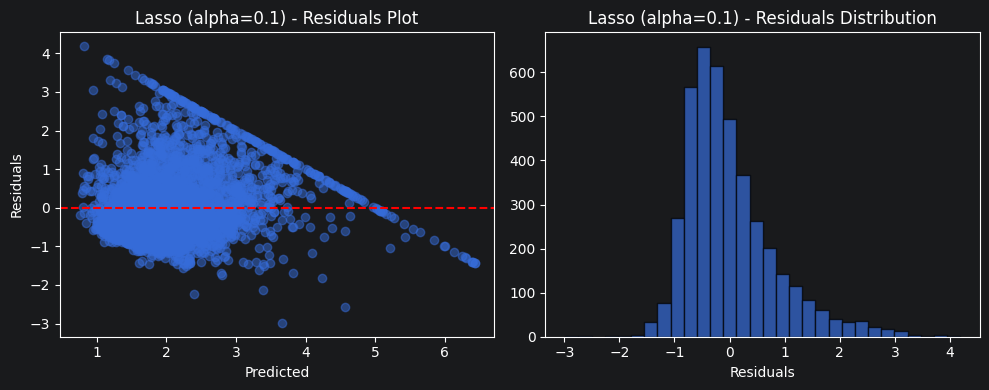

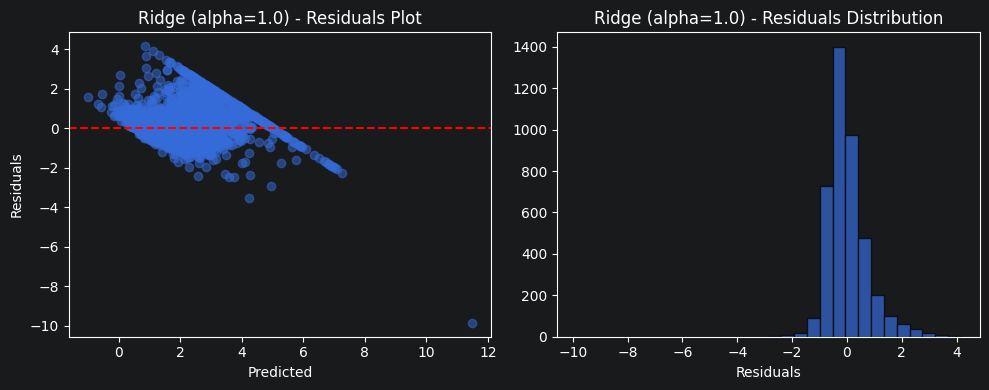

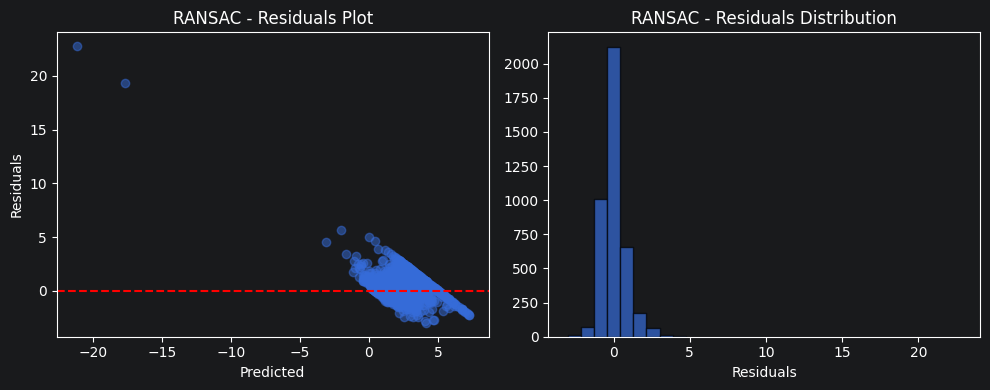


Сводная таблица метрик:
                       Train MSE   Test MSE Train MAE  Test MAE  Train R2  \
Linear Regression       0.517933   0.555892  0.528628    0.5332  0.612551   
Polynomial (degree=3)   0.342026  25.407137  0.416013  0.538679  0.744142   
Lasso (alpha=0.1)       0.671754   0.679552  0.619025  0.622148  0.497483   
Ridge (alpha=1.0)       0.517933   0.555851  0.528625  0.533193  0.612551   
RANSAC                 11.936221   0.787932  0.581319  0.553599 -7.929096   

                         Test R2  \
Linear Regression       0.575788   
Polynomial (degree=3) -18.388708   
Lasso (alpha=0.1)        0.48142   
Ridge (alpha=1.0)       0.575819   
RANSAC                  0.398713   

                                                                   Model  
Linear Regression                                     LinearRegression()  
Polynomial (degree=3)  (PolynomialFeatures(degree=3, include_bias=Fal...  
Lasso (alpha=0.1)                      Lasso(alpha=0.1, random_state=4

In [8]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Polynomial (degree=3)': make_pipeline(PolynomialFeatures(degree=3, include_bias=False), StandardScaler(),
                                           LinearRegression()),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, random_state=42),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'RANSAC': RANSACRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results[name] = {
        'Train MSE': mean_squared_error(y_train, y_train_pred),
        'Test MSE': mean_squared_error(y_test, y_test_pred),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred),
        'Train R2': r2_score(y_train, y_train_pred),
        'Test R2': r2_score(y_test, y_test_pred),
        'Model': model
    }

    residuals = y_test - y_test_pred
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.scatter(y_test_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')
    plt.title(f'{name} - Residuals Plot')

    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
    plt.xlabel('Residuals')
    plt.title(f'{name} - Residuals Distribution')
    plt.tight_layout()
    plt.show()

# Сводная таблица метрик
results_df = pd.DataFrame(results).T
print("\nСводная таблица метрик:")
print(results_df.round(4))

### Выводы по регрессии
1. Linear Regression показывает хорошие результаты, небольшая разница между Train и Test говорит об отсутствии переобучения.

2. PolynomialFeatures (степень 3) очень сильно переобучается

3. Lasso имеет результаты хуже чем у линейной регрессии, видимо выкинул полезные признаки

4. Ridge работает лучше примерно на том же уровне, как и линейная регрессия. Регуляризация сильно не на что не повлияла.

5. RANSAC обучился с огромной ошибкой. Этот метод вообще не подходит для этого датасета

### Пункт 3
> Применить методы KMeans и DBSCAN для кластеризации данных.

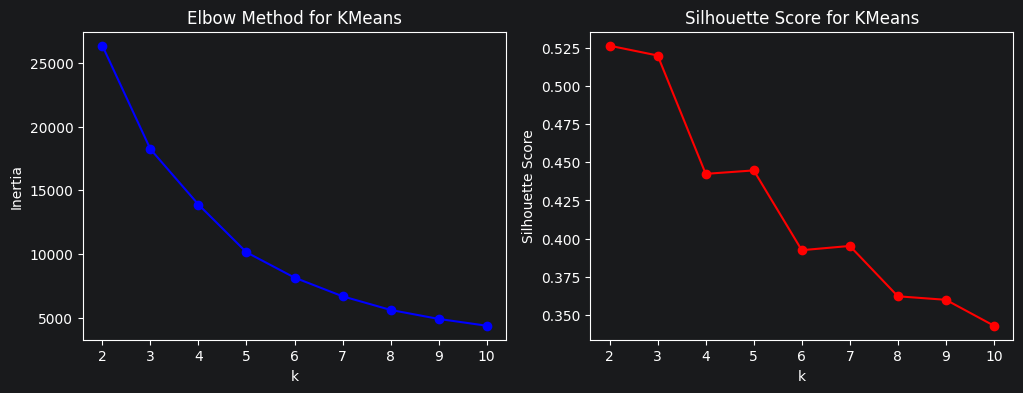

DBSCAN: найдено кластеров = 2, шума = 96


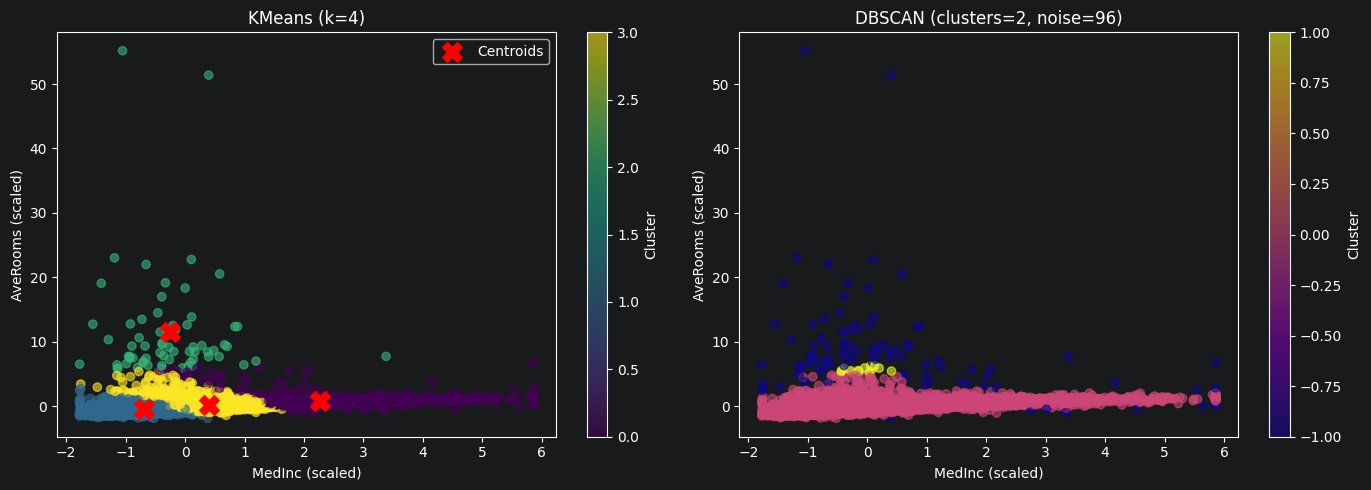


Средние значения по кластерам KMeans:
                MedInc  AveRooms  MedHouseVal
KMeans_Cluster                               
0                8.197     7.535        3.967
1                2.559     4.545        1.535
2                3.386    33.870        1.673
3                4.648     5.892        2.356

Средние значения по кластерам DBSCAN ( -1 = шум):
                MedInc  AveRooms  MedHouseVal
DBSCAN_Cluster                               
-1               4.747    27.188        2.021
 0               3.867     5.318        2.069
 1               3.725    19.581        1.837


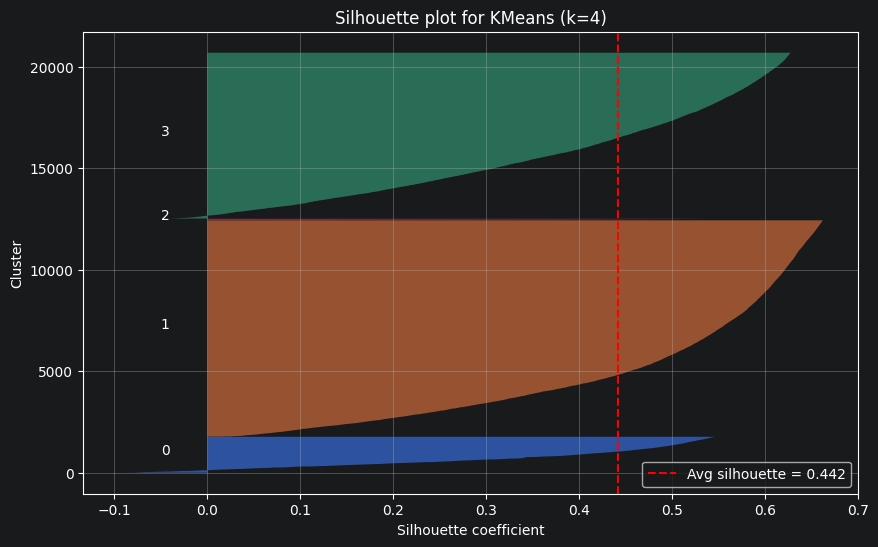

In [9]:
# Берем два признака для кластеризации и визуализации
X_clust = X_scaled[['MedInc', 'AveRooms']].values

# KMeans: правило локтя
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clust)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_clust, kmeans.labels_))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method for KMeans')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for KMeans')
plt.show()

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_clust)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
y_dbscan = dbscan.fit_predict(X_clust)
n_clusters_db = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise = list(y_dbscan).count(-1)

print(f"DBSCAN: найдено кластеров = {n_clusters_db}, шума = {n_noise}")

# Визуализация кластеров
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KMeans
scatter1 = axes[0].scatter(X_clust[:, 0], X_clust[:, 1], c=y_kmeans, cmap='viridis', alpha=0.6)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', c='red', s=200,
                label='Centroids')
axes[0].set_xlabel('MedInc (scaled)')
axes[0].set_ylabel('AveRooms (scaled)')
axes[0].set_title(f'KMeans (k={optimal_k})')
axes[0].legend()

# DBSCAN
scatter2 = axes[1].scatter(X_clust[:, 0], X_clust[:, 1], c=y_dbscan, cmap='plasma', alpha=0.6)
axes[1].set_xlabel('MedInc (scaled)')
axes[1].set_ylabel('AveRooms (scaled)')
axes[1].set_title(f'DBSCAN (clusters={n_clusters_db}, noise={n_noise})')

plt.colorbar(scatter1, ax=axes[0], label='Cluster')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')
plt.tight_layout()
plt.show()

# Анализ связи с целевой переменной
df_analysis = df.copy()
df_analysis['KMeans_Cluster'] = y_kmeans
df_analysis['DBSCAN_Cluster'] = y_dbscan

print("\nСредние значения по кластерам KMeans:")
print(df_analysis.groupby('KMeans_Cluster')[['MedInc', 'AveRooms', 'MedHouseVal']].mean().round(3))

print("\nСредние значения по кластерам DBSCAN ( -1 = шум):")
print(df_analysis.groupby('DBSCAN_Cluster')[['MedInc', 'AveRooms', 'MedHouseVal']].mean().round(3))

# Silhouette plot для KMeans
sil_samples = silhouette_samples(X_clust, y_kmeans)
fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i in range(optimal_k):
    ith_cluster_sil = sil_samples[y_kmeans == i]
    ith_cluster_sil.sort()
    size_cluster = ith_cluster_sil.shape[0]
    y_upper = y_lower + size_cluster
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
    y_lower = y_upper + 10

ax.axvline(x=np.mean(sil_samples), color='red', linestyle='--', label=f'Avg silhouette = {np.mean(sil_samples):.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette plot for KMeans (k={optimal_k})')
ax.legend()
ax.grid(True)
plt.show()

### Выводы по кластеризации
#### KMeans (k=4)
Чёткая градация по доходу и цене: Кластер 0 (высокий доход 8.2, цена 4) — дорогое жильё, кластер 1 (низкий доход 2.6, цена 1.5) — дешёвое.

В кластере 2 очень высокое число комнат (33.9), но цена низкая (1.7) — возможно это какие-нибудь общежития, ну или дома с маленькими квартирами

Кластеры хорошо интерпретируются и логично связаны с диапазонами исходных признаков.

#### DBSCAN
Всего 2 кластера + шум 96: DBSCAN хуже различает градации цены.

Шумовые точки (кластер -1): средний доход (4.7) и очень много комнат (27.2)

Кластеры 0 и 1 различаются в основном по AveRooms (5.3 и 19.6), но по цене почти одинаковы (2.07 и 1.84) - значит, для цены важнее доход, а не число комнат.

Вывод: DBSCAN менее подходит для этого датасета из-за неоднородной плотности точек.